C:\Users\hp\Documents\weeko-challenge\Climate-Challenge-Week0
Duplicates: 0
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month          0.0
dtype: float64
Total outlier points: 102


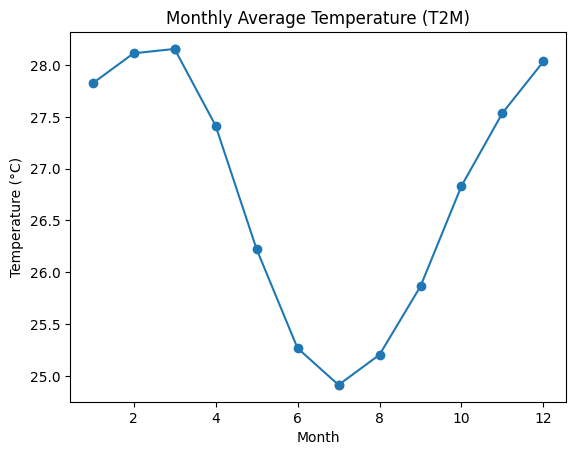

Warmest month: 3
Coldest month: 7


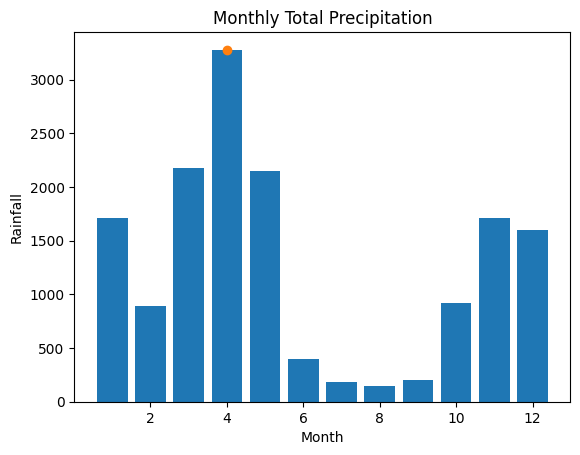

Peak rainy month: 4


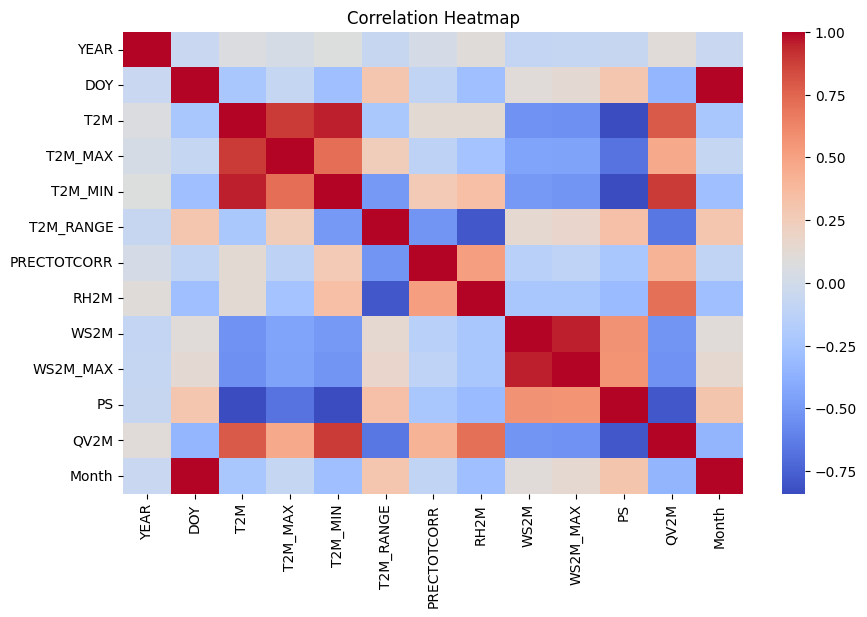

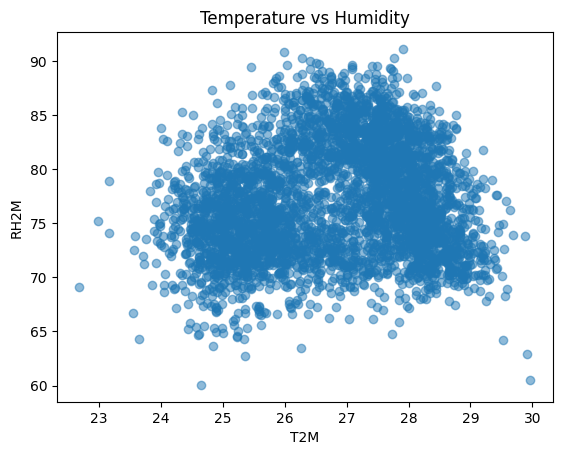

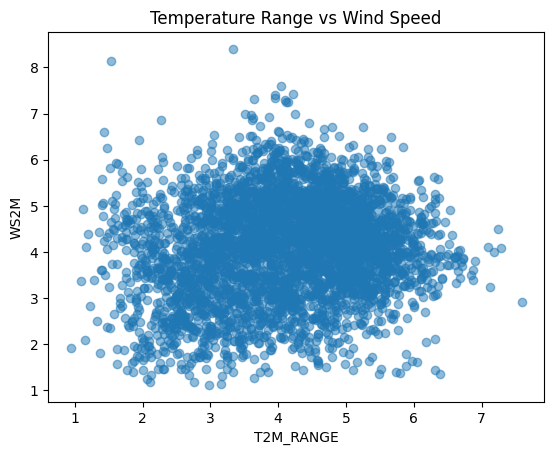

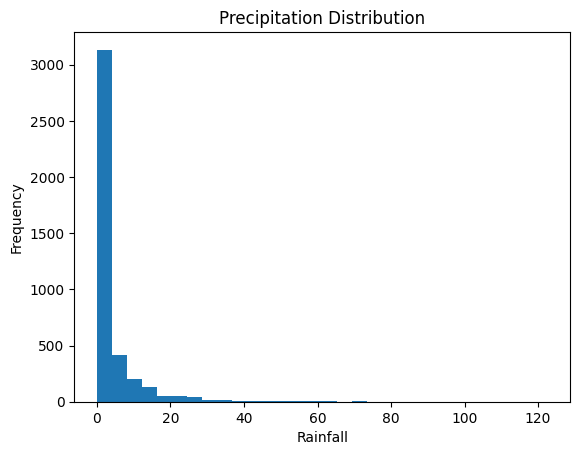

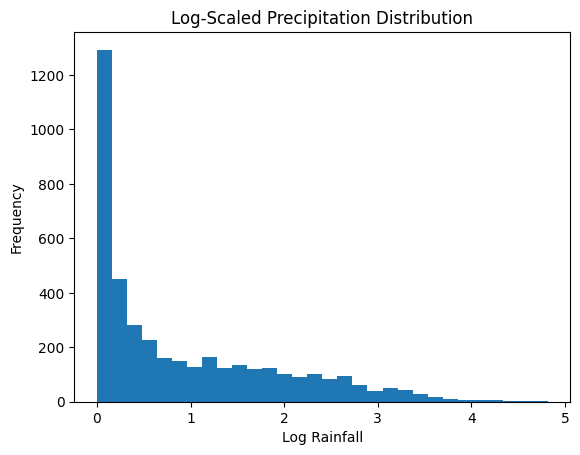

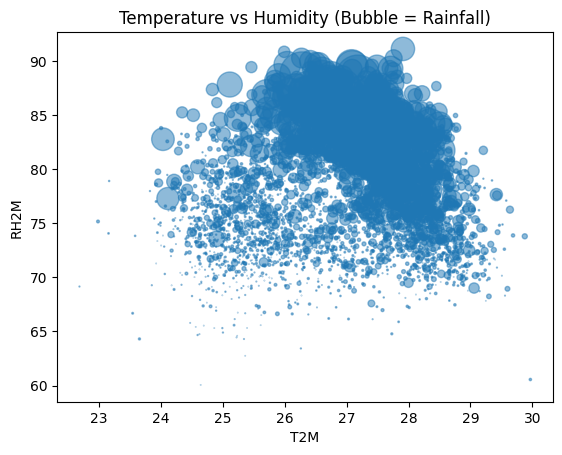

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
print(os.getcwd())

df = pd.read_csv("data/tanzania.csv")
df["Country"] = "tanzania"

df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

df = df.replace(-999, np.nan)

df.duplicated().sum()
df = df.drop_duplicates()
print("Duplicates:", df.duplicated().sum())

df.describe()
df.isna().sum()
missing_pct = df.isna().mean() * 100
print(missing_pct)

from scipy import stats

cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z = np.abs(stats.zscore(df[cols], nan_policy='omit'))

outliers = (z > 3).sum().sum()
print("Total outlier points:", outliers)

df = df[df.isna().mean(axis=1) < 0.3]
df = df.sort_values("Date").ffill()

df.to_csv("data/tanzania_clean.csv", index=False)

df_monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure()
plt.plot(df_monthly_temp.index, df_monthly_temp.values, marker="o")
plt.title("Monthly Average Temperature (T2M)")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")

warmest = df_monthly_temp.idxmax()
coldest = df_monthly_temp.idxmin()

plt.scatter(warmest, df_monthly_temp.max())
plt.scatter(coldest, df_monthly_temp.min())

plt.show()

print("Warmest month:", warmest)
print("Coldest month:", coldest)

df_monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.figure()
plt.bar(df_monthly_rain.index, df_monthly_rain.values)
plt.title("Monthly Total Precipitation")
plt.xlabel("Month")
plt.ylabel("Rainfall")

peak_rain = df_monthly_rain.idxmax()
plt.scatter(peak_rain, df_monthly_rain.max())

plt.show()

print("Peak rainy month:", peak_rain)

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

plt.figure()
plt.scatter(df["T2M"], df["RH2M"], alpha=0.5)
plt.title("Temperature vs Humidity")
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.show()

df["T2M_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]

plt.figure()
plt.scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.5)
plt.title("Temperature Range vs Wind Speed")
plt.xlabel("T2M_RANGE")
plt.ylabel("WS2M")
plt.show()

plt.figure()
plt.hist(df["PRECTOTCORR"].dropna(), bins=30)
plt.title("Precipitation Distribution")
plt.xlabel("Rainfall")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(np.log1p(df["PRECTOTCORR"].dropna()), bins=30)
plt.title("Log-Scaled Precipitation Distribution")
plt.xlabel("Log Rainfall")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"] * 10,  # bubble size
    alpha=0.5
)

plt.title("Temperature vs Humidity (Bubble = Rainfall)")
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.show()

# Analysis Summary

## Temperature
Temperature shows seasonal variation with peaks in warmer months.

## Rainfall
Rainfall shows strong seasonal variation with wet and dry periods.

## Correlation
Temperature variables are strongly correlated; humidity shows weak negative relationship.

## Scatter Analysis
Temperature and humidity show weak inverse relationship.

## Distribution
Rainfall is highly skewed with occasional extreme values.